# Week 5: Classification with Logistic Regression
## News headline classification practical

Use the same headline data as Week 4 to learn how logistic regression converts a weighted score into a probability, and how a threshold converts that probability into a class.

Run the cells in order. Keep `news_dataset.csv` in the working directory and use a Python environment with the packages listed in `requirements.txt`.

**Inputs and labels:** the model uses `title` to predict the recorded `label`. The file contains classes `0` and `1`; their original definitions have not been supplied. Retain those names until source documentation confirms them. The model learns associations with the recorded labels and does not independently verify a news claim.

**Positive class this week:** Class 1. Precision, recall, and F1 in this notebook refer to Class 1 unless a metric is explicitly named **macro F1**. This differs from the Class 0 calculation used in Week 4.

**Evaluation:** the partition used for the Week 4 final test is reused here as a classroom benchmark. Its results were already viewed, so it is **not a fresh independent test set** for the course. We still choose this week's model settings using validation data only. A future deployment decision needs a new independent evaluation.


## 1. Import the tools

`LogisticRegression` learns a linear score for classification. `CountVectorizer` creates the same word-count features used in Week 4. We also retain Naive Bayes and the majority-class rule for comparison.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, log_loss


## 2. Calculate probabilities from an invented score

For a headline represented by word counts, logistic regression uses

$$z=b+\sum_j w_jx_j,\qquad p=P(y=1\mid x)=\sigma(z)=\frac{1}{1+e^{-z}}.$$

Use this **invented teaching rule**, whose weights are supplied rather than learned:

$$z=-1+\text{report count}-\text{shocking count}.$$

1. For “market report report”, set report count to 2 and shocking count to 0. Find $z$ and $p$.
2. For “shocking report”, set report count to 1 and shocking count to 1. Find $z$ and $p$.
3. Predict Class 1 if $p\geq0.5$ and Class 0 otherwise.

The real news model later learns thousands of weights. These two invented weights are only for the calculation exercise.


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

toy = pd.DataFrame({
    "headline": ["market report report", "shocking report"],
    "report_count": [2, 1], "shocking_count": [0, 1], "label": [1, 0]
})
toy["z"] = -1 + toy["report_count"] - toy["shocking_count"]
toy["P(Class 1)"] = sigmoid(toy["z"])
toy["prediction"] = (toy["P(Class 1)"] >= 0.5).astype(int)
print(toy.round(4).to_string(index=False))


            headline  report_count  shocking_count  label  z  P(Class 1)  prediction
market report report             2               0      1  1      0.7311           1
     shocking report             1               1      0 -1      0.2689           0


### Calculate binary log loss

For an observed label $y\in\{0,1\}$ and probability $p$ for Class 1,

$$\ell(y,p)=-\left[y\log(p)+(1-y)\log(1-p)\right].$$

- If $y=1$, the loss is $-\log(p)$.
- If $y=0$, the loss is $-\log(1-p)$.

The mean over all examples is the average log loss. The logarithm is the natural logarithm. Confident wrong predictions receive a large loss.

Use the invented labels in the table above to calculate both losses and their mean. Then calculate the loss for a Class 1 example when the model assigns $p=0.1192$.


In [5]:
y_toy = toy["label"].to_numpy()
p_toy = toy["P(Class 1)"].to_numpy()
toy["log_loss"] = -(y_toy * np.log(p_toy)
                    + (1 - y_toy) * np.log(1 - p_toy))
print(toy[["headline", "label", "P(Class 1)", "log_loss"]]
      .round(4).to_string(index=False))
print(f"Mean log loss: {toy['log_loss'].mean():.4f}")
print(f"Wrong, confident Class 1 prediction loss: {-np.log(sigmoid(-2)):.4f}")


            headline  label  P(Class 1)  log_loss
market report report      1      0.7311    0.3133
     shocking report      0      0.2689    0.3133
Mean log loss: 0.3133
Wrong, confident Class 1 prediction loss: 2.1269


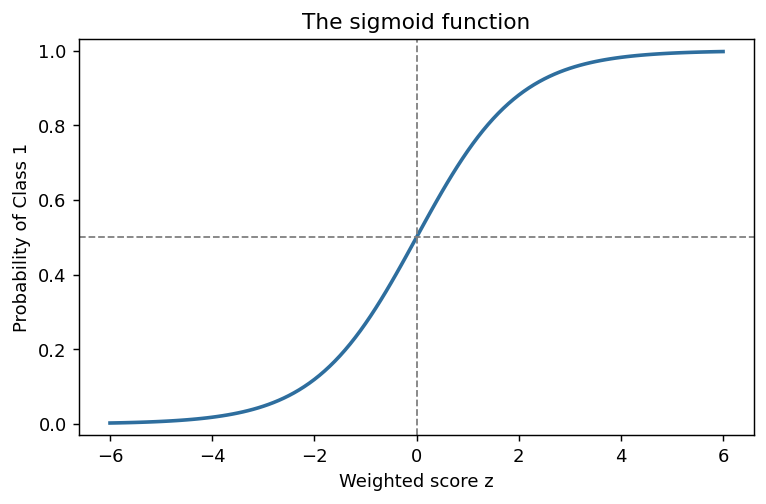

In [4]:
z_values = np.linspace(-6, 6, 121)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(z_values, sigmoid(z_values), color="#2E6E9E", linewidth=2)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set(xlabel="Weighted score z", ylabel="Probability of Class 1",
       title="The sigmoid function", ylim=(-0.03, 1.03))
plt.tight_layout()
plt.show()


## 3. Read the same news data

The original file contains 6,000 rows. The title is the model input; `label` is the target. We exclude `subject`, `date`, and the article body. In this file, subject categories are tied to labels, making `subject` an easy shortcut.

The alternate filename is supported if your downloaded file is named `news_dataset(1).csv`.


In [6]:
csv_path = Path("news_dataset.csv")
if not csv_path.exists():
    csv_path = Path("news_dataset(1).csv")
raw = pd.read_csv(csv_path)
print("Shape:", raw.shape)
print("Columns:", raw.columns.tolist())
print(raw["label"].value_counts().sort_index().to_string())
assert set(raw["label"].unique()) == {0, 1}


Shape: (6000, 5)
Columns: ['title', 'text', 'subject', 'date', 'label']
label
0    3000
1    3000


## 4. Repeat the Week 4 cleaning rules

1. Normalize text for duplicate checks by ignoring capitalization and extra spaces.
2. Remove empty titles and repeated normalized titles.
3. Remove repeated nonempty normalized bodies. Retain blank bodies because only titles enter the model.

The rules remove identical examples before splitting. They do not remove every paraphrase or closely related story. No predictive vocabulary is learned during this step.


In [7]:
news = raw.copy()
for column in ["title", "text"]:
    news[column] = news[column].fillna("").astype(str)
news["title_key"] = news["title"].str.lower().str.replace(
    r"\s+", " ", regex=True).str.strip()
news["body_key"] = news["text"].str.lower().str.replace(
    r"\s+", " ", regex=True).str.strip()


In [8]:
news = news.loc[news["title_key"].ne("")].copy()
before_title = len(news)
news = news.drop_duplicates("title_key").copy()
removed_titles = before_title - len(news)
repeat = news["body_key"].ne("") & news["body_key"].duplicated()
removed_bodies = int(repeat.sum())
news = news.loc[~repeat].copy()
print("Repeated titles removed:", removed_titles)
print("Additional repeated bodies removed:", removed_bodies)
print("Rows retained:", len(news))


Repeated titles removed: 116
Additional repeated bodies removed: 1
Rows retained: 5883


## 5. Reproduce the training, validation, and benchmark partitions

We use the same stratified split and random seed as Week 4. The result is 3,529 training rows, 1,177 validation rows, and 1,177 rows in the reused benchmark partition.

Training data determines the vocabulary and model parameters. Validation data selects the settings. The reused benchmark allows a direct classroom comparison with Week 4; it is not a new independent test.


In [9]:
train, held_out = train_test_split(
    news, test_size=0.40, stratify=news["label"], random_state=42
)
valid, test = train_test_split(
    held_out, test_size=0.50, stratify=held_out["label"], random_state=42
)
y_train, y_valid, y_test = train["label"], valid["label"], test["label"]
print("Training, validation, reused benchmark:", len(train), len(valid), len(test))
print(pd.DataFrame({"Training": y_train.value_counts(),
                    "Validation": y_valid.value_counts(),
                    "Benchmark": y_test.value_counts()}).sort_index().to_string())


Training, validation, reused benchmark: 3529 1177 1177
       Training  Validation  Benchmark
label                                 
0          1737         579        580
1          1792         598        597


## 6. Create word-count features

Fit `CountVectorizer` on training headlines only. Transform validation and benchmark headlines using that fixed vocabulary. Words absent from the training vocabulary are ignored.

The settings match Week 4: a fixed English stop-word list and words appearing in at least two training headlines. The sparse matrices store nonzero counts efficiently.


In [10]:
counts = CountVectorizer(stop_words="english", min_df=2)
X_train = counts.fit_transform(train["title"])
X_valid = counts.transform(valid["title"])
X_test = counts.transform(test["title"])
print("Training matrix:", X_train.shape)
print("Validation matrix:", X_valid.shape)
print("Reused benchmark matrix:", X_test.shape)


Training matrix: (3529, 3777)
Validation matrix: (1177, 3777)
Reused benchmark matrix: (1177, 3777)


## 7. Fit a first logistic regression model

Use `C=1.0`, `solver="lbfgs"`, and `max_iter=2000`.

- The coefficients and intercept are learned from the training data.
- `C` controls inverse regularization strength: a smaller `C` means stronger regularization.
- `max_iter` is the maximum number of optimization iterations, not a requirement to run that many.
- `lbfgs` is the numerical optimizer used for fitting. It is not the hand-calculated gradient descent update from Week 3.

The default logistic regression model uses L2 regularization in the installed implementation. Later we compare a small set of `C` values using validation macro F1.


In [11]:
model = LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000)
model.fit(X_train, y_train)
print("Class order:", model.classes_)
print(f"Intercept: {model.intercept_[0]:.4f}")
print("Optimization iterations:", model.n_iter_[0])


Class order: [0 1]
Intercept: 1.0479
Optimization iterations: 22


/Users/anansi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/anansi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/anansi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


### Convert probabilities into classes

`predict_proba` returns probabilities in `classes_` order. Locate the column for Class 1 explicitly. A decision threshold $t$ gives

$$\hat y=\begin{cases}1 & p\geq t\\0 & p<t.\end{cases}$$

The probability and the class prediction are different outputs. Changing the threshold does not retrain the model or change its probabilities.


In [12]:
class1_column = int(np.flatnonzero(model.classes_ == 1)[0])
p_valid_base = model.predict_proba(X_valid)[:, class1_column]
pred_valid_base = (p_valid_base >= 0.5).astype(int)
print(pd.DataFrame({
    "actual": y_valid.to_numpy()[:5],
    "P(Class 1)": p_valid_base[:5],
    "prediction": pred_valid_base[:5]
}).round(4).to_string(index=False))


 actual  P(Class 1)  prediction
      0      0.0195           0
      1      0.4455           0
      0      0.0016           0
      0      0.3223           0
      0      0.0132           0


## 8. Evaluate the first model

Class 1 is positive throughout this practical. With matrix rows ordered `[0, 1]` and columns ordered `[0, 1]`, the layout is `[[TN, FP], [FN, TP]]`.

$$\text{Precision}_1=\frac{TP}{TP+FP},\quad
\text{Recall}_1=\frac{TP}{TP+FN},\quad
F_{1,1}=\frac{2TP}{2TP+FP+FN}.$$

Macro F1 averages the F1 score of Class 0 and Class 1. We use macro F1 for model selection and report log loss separately to assess the probability output. These metrics answer different questions.


In [13]:
def evaluate(y, prediction):
    tn, fp, fn, tp = confusion_matrix(y, prediction, labels=[0, 1]).ravel()
    return {"accuracy": accuracy_score(y, prediction),
            "precision": precision_score(y, prediction, pos_label=1, zero_division=0),
            "recall": recall_score(y, prediction, pos_label=1, zero_division=0),
            "f1": f1_score(y, prediction, pos_label=1, zero_division=0),
            "macro_f1": f1_score(y, prediction, average="macro", zero_division=0),
            "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
            "selected_count": int(np.asarray(prediction).sum())}


In [14]:
base_metrics = evaluate(y_valid, pred_valid_base)
print(pd.Series(base_metrics).round(4).to_string())
print(f"Validation log loss: {log_loss(y_valid, p_valid_base):.4f}")
print("Confusion matrix: rows actual, columns predicted, class order [0, 1]")
print(confusion_matrix(y_valid, pred_valid_base, labels=[0, 1]))


accuracy            0.8870
precision           0.8475
recall              0.9482
f1                  0.8950
macro_f1            0.8863
TP                567.0000
FP                102.0000
FN                 31.0000
TN                477.0000
selected_count    669.0000
Validation log loss: 0.2631
Confusion matrix: rows actual, columns predicted, class order [0, 1]
[[477 102]
 [ 31 567]]


## 9. Compare regularization settings using validation data

Compare `C` values `0.1`, `1.0`, and `10.0`, keeping the threshold at `0.5`. Choose the largest validation macro F1. If there is an exact tie, choose the smaller `C`.

Only `C` changes here. The text features, partitions, solver, and iteration limit remain fixed. Selection uses full-precision scores, not the rounded display values.


In [15]:
models, c_rows = {}, []
for C in [0.1, 1.0, 10.0]:
    candidate = LogisticRegression(C=C, solver="lbfgs", max_iter=2000)
    candidate.fit(X_train, y_train)
    p = candidate.predict_proba(X_valid)[:, 1]
    models[C] = candidate
    c_rows.append({"C": C, **evaluate(y_valid, (p >= 0.5).astype(int)),
                   "log_loss": log_loss(y_valid, p)})
c_results = pd.DataFrame(c_rows).sort_values(
    ["macro_f1", "C"], ascending=[False, True])
print(c_results[["C", "accuracy", "macro_f1", "log_loss"]].round(4).to_string(index=False))


   C  accuracy  macro_f1  log_loss
10.0    0.8904    0.8900    0.2816
 1.0    0.8870    0.8863    0.2631
 0.1    0.8760    0.8747    0.3521


/Users/anansi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/anansi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/anansi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/anansi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/anansi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_lin

In [16]:
best_C = float(c_results.iloc[0]["C"])
final_model = models[best_C]
assert np.array_equal(final_model.classes_, [0, 1])
p_valid = final_model.predict_proba(X_valid)[:, 1]
print("Selected C:", best_C)
print(f"Selected model intercept: {final_model.intercept_[0]:.4f}")


Selected C: 10.0
Selected model intercept: 1.7891


## 10. Examine the threshold trade-off

Keep the selected model fixed and compare thresholds `0.3`, `0.5`, and `0.7` on the validation set. `selected_count` is the number predicted as Class 1.

Lowering the threshold selects at least as many examples as Class 1. This cannot reduce recall for the same fixed scores, but the effect on precision depends on which additional examples are selected. In this dataset, the lower threshold trades lower precision for higher recall.

For the worked example, select the threshold with the highest validation macro F1. Break an exact tie by choosing the threshold closest to `0.5`, and then the smaller threshold. This is a classroom selection rule; a real application should connect the choice to the cost of each kind of error.


In [17]:
threshold_rows = []
for threshold in [0.3, 0.5, 0.7]:
    prediction = (p_valid >= threshold).astype(int)
    threshold_rows.append({"threshold": threshold, **evaluate(y_valid, prediction)})
threshold_results = pd.DataFrame(threshold_rows)
print(threshold_results.round(4).to_string(index=False))


 threshold  accuracy  precision  recall     f1  macro_f1  TP  FP  FN  TN  selected_count
       0.3    0.8717     0.8126  0.9716 0.8850     0.870 581 134  17 445             715
       0.5    0.8904     0.8591  0.9381 0.8969     0.890 561  92  37 487             653
       0.7    0.8811     0.8817  0.8846 0.8831     0.881 529  71  69 508             600


In [18]:
ranking = threshold_results.assign(
    distance=(threshold_results["threshold"] - 0.5).abs()
).sort_values(["macro_f1", "distance", "threshold"], ascending=[False, True, True])
chosen_threshold = float(ranking.iloc[0]["threshold"])
print("Selected threshold:", chosen_threshold)


Selected threshold: 0.5


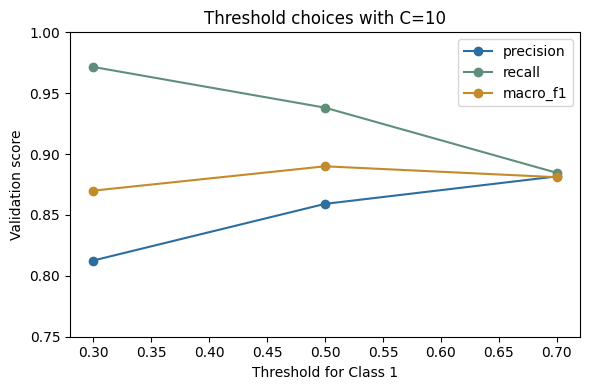

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
for metric, color in [("precision", "#2E6E9E"), ("recall", "#5F8F7B"),
                      ("macro_f1", "#C58B2A")]:
    ax.plot(threshold_results["threshold"], threshold_results[metric],
            marker="o", label=metric, color=color)
ax.set(xlabel="Threshold for Class 1", ylabel="Validation score",
       title=f"Threshold choices with C={best_C:g}", ylim=(0.75, 1.0))
ax.legend()
plt.tight_layout()
plt.show()
